# 04 - Anomaly Detection (Layer 3)

Checkpoints: 5.1 (train), 5.2 (visualize), 5.3 (sanity check)

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import IsolationForest
from ml.config import (
    LABELED_CSV, CRITICALITY_LEVELS,
    EMBEDDINGS_CACHE_PATH, ANOMALY_MODEL_PATH,
    ISOLATION_FOREST_CONTAMINATION,
    ISOLATION_FOREST_N_ESTIMATORS,
    ISOLATION_FOREST_RANDOM_STATE,
    RANDOM_STATE, MODELS_DIR,
)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
CRIT_COLORS = {'HIGH':'#d62728','MEDIUM':'#ff7f0e','LOW':'#1f77b4','INFO':'#2ca02c'}
MODELS_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs('../notebooks/figures', exist_ok=True)
print('Ready.')

Ready.


In [11]:
df = pd.read_csv(LABELED_CSV)
df = df[~df['reason'].str.startswith('LABELING_FAILED', na=False)].copy()
df = df[df['text'].notna() & (df['text'].str.strip() != '')].copy()
df['criticality'] = pd.Categorical(df['criticality'], categories=CRITICALITY_LEVELS, ordered=True)
df = df.reset_index(drop=True)
embeddings = np.load(EMBEDDINGS_CACHE_PATH)
assert len(embeddings) == len(df)
print(f'Loaded {len(df):,} NOTAMs, embeddings {embeddings.shape}')

Loaded 3,945 NOTAMs, embeddings (3945, 384)


---
## Checkpoint 5.1 - Train Isolation Forest

In [12]:
iso = IsolationForest(
    n_estimators=ISOLATION_FOREST_N_ESTIMATORS,
    contamination=ISOLATION_FOREST_CONTAMINATION,
    random_state=ISOLATION_FOREST_RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(embeddings)
df['anomaly_score'] = -iso.decision_function(embeddings)
df['is_anomaly']    = iso.predict(embeddings) == -1
joblib.dump(iso, ANOMALY_MODEL_PATH)
n = df['is_anomaly'].sum()
print(f'Flagged {n:,} anomalies ({n/len(df)*100:.1f}%)')
print(f'Saved -> {ANOMALY_MODEL_PATH.name}')
print('Checkpoint 5.1 done')

Flagged 198 anomalies (5.0%)
Saved -> isolation_forest.pkl
Checkpoint 5.1 done


---
## Checkpoint 5.2 - Visualizations

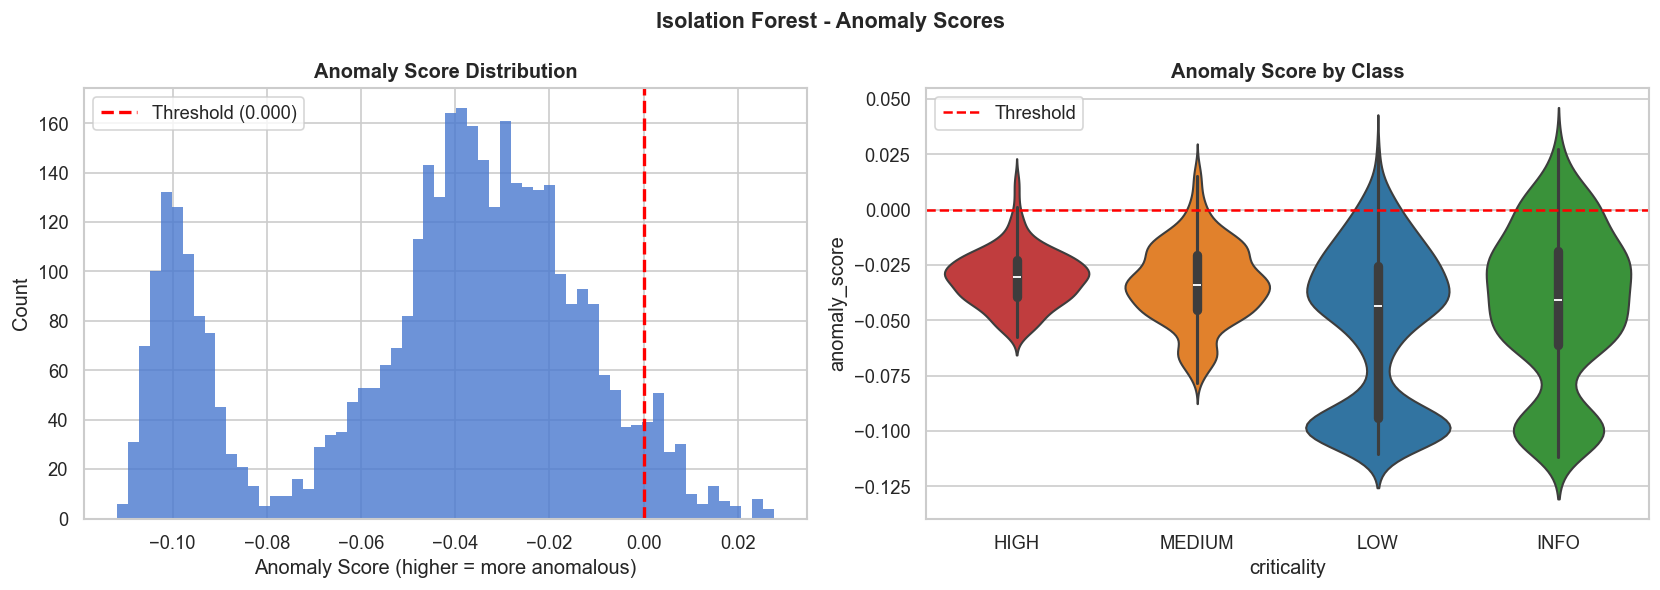

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
threshold = df[df['is_anomaly']]['anomaly_score'].min()

axes[0].hist(df['anomaly_score'], bins=60, color='#4878cf', alpha=0.8, edgecolor='none')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')
axes[0].set_title('Anomaly Score Distribution', fontweight='bold')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.violinplot(data=df, x='criticality', y='anomaly_score',
               order=CRITICALITY_LEVELS, palette=CRIT_COLORS, ax=axes[1], inner='box')
axes[1].axhline(threshold, color='red', linestyle='--', linewidth=1.5, label='Threshold')
axes[1].set_title('Anomaly Score by Class', fontweight='bold')
axes[1].legend()

plt.suptitle('Isolation Forest - Anomaly Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/anomaly_scores.png', bbox_inches='tight')
plt.show()

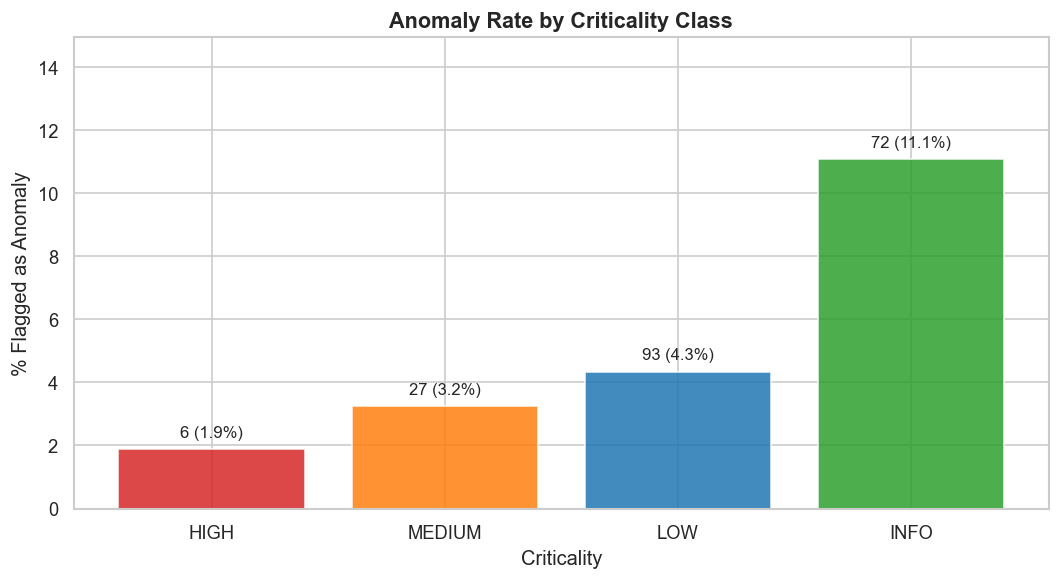

             Anomalies  Total  Anomaly %
criticality                             
HIGH                 6    319   1.880878
MEDIUM              27    833   3.241297
LOW                 93   2143   4.339711
INFO                72    650  11.076923


In [14]:
anomaly_by_class = df.groupby('criticality')['is_anomaly'].agg(['sum','count'])
anomaly_by_class['pct'] = anomaly_by_class['sum'] / anomaly_by_class['count'] * 100
anomaly_by_class = anomaly_by_class.reindex(CRITICALITY_LEVELS)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(anomaly_by_class.index, anomaly_by_class['pct'],
              color=[CRIT_COLORS[c] for c in anomaly_by_class.index], alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(bars, anomaly_by_class.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{int(row['sum'])} ({row['pct']:.1f}%)", ha='center', va='bottom', fontsize=10)
ax.set_title('Anomaly Rate by Criticality Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Criticality')
ax.set_ylabel('% Flagged as Anomaly')
ax.set_ylim(0, anomaly_by_class['pct'].max() * 1.35)
plt.tight_layout()
plt.savefig('../notebooks/figures/anomaly_by_class.png', bbox_inches='tight')
plt.show()
print(anomaly_by_class[['sum','count','pct']].rename(columns={'sum':'Anomalies','count':'Total','pct':'Anomaly %'}).to_string())

Reducing 2,000 embeddings to 2D...


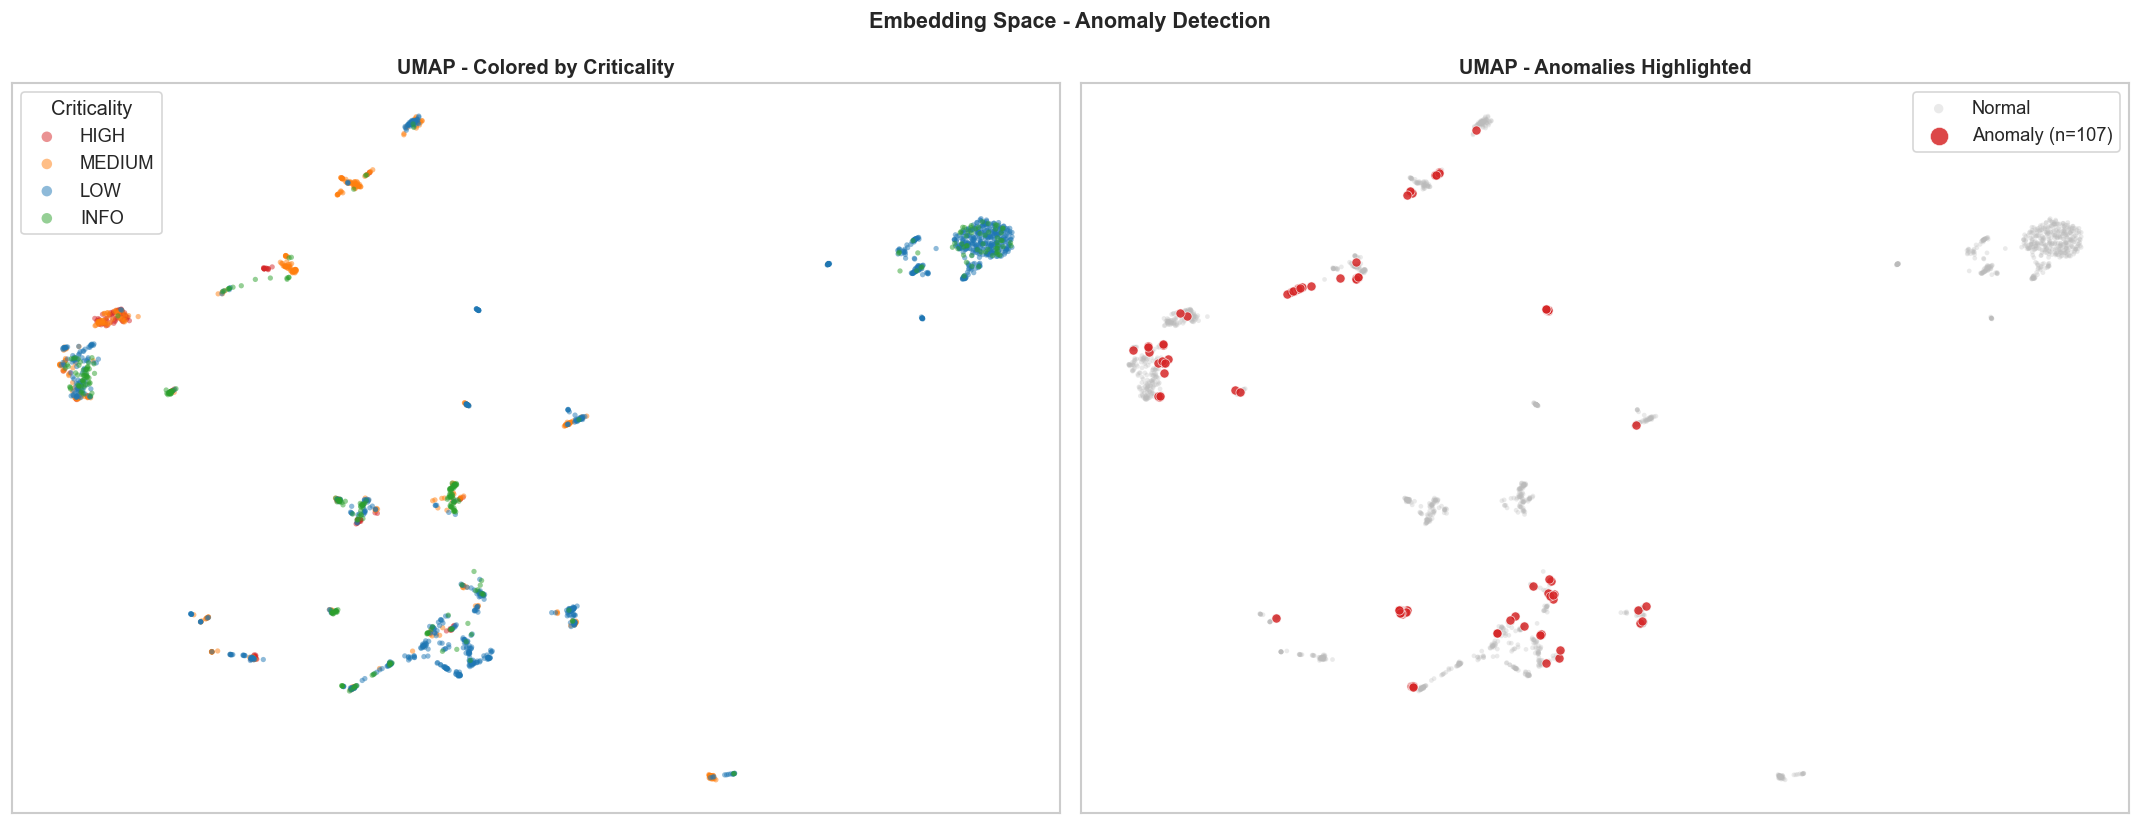

Checkpoint 5.2 done


In [15]:
try:
    import umap as umap_lib
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('UMAP not found - using t-SNE. Install with: pip install umap-learn')

SAMPLE_SIZE = min(2000, len(embeddings))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx     = rng.choice(len(embeddings), SAMPLE_SIZE, replace=False)
sample_emb     = embeddings[sample_idx]
sample_y       = df['criticality'].values[sample_idx]
sample_anomaly = df['is_anomaly'].values[sample_idx]

print(f'Reducing {SAMPLE_SIZE:,} embeddings to 2D...')
if UMAP_AVAILABLE:
    reducer = umap_lib.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
    method = 'UMAP'
else:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=40, random_state=RANDOM_STATE, n_iter=1000)
    method = 't-SNE'

coords = reducer.fit_transform(sample_emb)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for crit in CRITICALITY_LEVELS:
    mask = sample_y == crit
    axes[0].scatter(coords[mask,0], coords[mask,1], c=CRIT_COLORS[crit],
                    label=crit, alpha=0.5, s=10, edgecolors='none')
axes[0].set_title(f'{method} - Colored by Criticality', fontweight='bold')
axes[0].legend(markerscale=2, title='Criticality')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].scatter(coords[~sample_anomaly,0], coords[~sample_anomaly,1],
                c='#bbbbbb', alpha=0.3, s=8, edgecolors='none', label='Normal')
axes[1].scatter(coords[sample_anomaly,0], coords[sample_anomaly,1],
                c='#d62728', alpha=0.85, s=30, edgecolors='white',
                linewidths=0.4, label=f'Anomaly (n={sample_anomaly.sum()})', zorder=5)
axes[1].set_title(f'{method} - Anomalies Highlighted', fontweight='bold')
axes[1].legend(markerscale=2)
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle('Embedding Space - Anomaly Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/umap_anomalies.png', bbox_inches='tight', dpi=150)
plt.show()
print('Checkpoint 5.2 done')

---
## Checkpoint 5.3 - Manual Sanity Check

Read the top anomalies. They should look genuinely unusual.

**Good signs:** long/complex text, rare event types (laser, space ops), unusual airspace combos

**Bad signs:** completely routine NOTAMs at the top -> lower contamination to 0.03 in config.py

In [16]:
top_anomalies = df.nlargest(20, 'anomaly_score')[
    ['id','icao_location','classification','criticality','anomaly_score','text','reason']
].reset_index(drop=True)

print('TOP 20 MOST ANOMALOUS NOTAMs')
print('=' * 70)
for i, row in top_anomalies.iterrows():
    print(f"\nRank {i+1:2d} | Score: {row['anomaly_score']:.4f} | {row['criticality']:6s} | {row['icao_location']}")
    print(f"  Text:   {str(row['text'])[:120]}")
    print(f"  Reason: {str(row['reason'])[:100]}")
    print('-' * 70)

TOP 20 MOST ANOMALOUS NOTAMs

Rank  1 | Score: 0.0276 | LOW    | KTEL
  Text:   APRON RUNUP PAD SFC MARKING NOT STD
  Reason: Non-standard surface markings at distant airport don't affect KOKC-KJFK flight operations.
----------------------------------------------------------------------

Rank  2 | Score: 0.0275 | LOW    | KAJG
  Text:   SVC AUTOMATED WX BCST SYSTEM UNREL
  Reason: Weather broadcast system outage at alternate airport, minor operational impact.
----------------------------------------------------------------------

Rank  3 | Score: 0.0272 | INFO   | KSZL
  Text:   ENGINE RUNS PROHIBITED ON PARKING SPOT KILO 1.
  Reason: Military base parking restriction unrelated to commercial flight route.
----------------------------------------------------------------------

Rank  4 | Score: 0.0254 | LOW    | KJST
  Text:   IAP JOHN MURTHA JOHNSTOWN/CAMBRIA COUNTY, JOHNSTOWN, PA. VOR Y RWY 15, AMDT 9B... VOR Z RWY 15, AMDT 7B... PROCEDURE NA.
  Reason: VOR approach procedures unavaila

In [17]:
print('Criticality distribution of top 20:')
print(top_anomalies['criticality'].value_counts().to_string())
print('\nClassification distribution of top 20:')
print(top_anomalies['classification'].value_counts().to_string())
print('\nTop locations:')
print(top_anomalies['icao_location'].value_counts().head(10).to_string())

Criticality distribution of top 20:
criticality
LOW       8
INFO      8
MEDIUM    4
HIGH      0

Classification distribution of top 20:
classification
DOM     11
MIL      5
INTL     3
FDC      1

Top locations:
icao_location
KSZL    4
KTEB    2
KTEL    1
KAJG    1
KJST    1
KGMJ    1
KXNA    1
KCVG    1
KUNO    1
KHMZ    1


---
## Known Limitations

Honest assessment of what the anomaly detection does and does not do well.
This section belongs in your README and is a talking point in interviews.

---
## Phase 5 Summary

In [18]:
# Airport frequency in the dataset
airport_counts = df['icao_location'].value_counts()

# Flag which anomalies come from rare airports (fewer than 5 NOTAMs total)
rare_threshold = 5
top_anomalies['airport_total_notams'] = top_anomalies['icao_location'].map(
    lambda x: airport_counts.get(x, 0)
)
top_anomalies['likely_rare_airport'] = top_anomalies['airport_total_notams'] < rare_threshold

rare_driven    = top_anomalies['likely_rare_airport'].sum()
content_driven = len(top_anomalies) - rare_driven

print('TOP 20 ANOMALIES - AIRPORT FREQUENCY ANALYSIS')
print('=' * 65)
for _, row in top_anomalies.iterrows():
    flag     = '  <- rare airport' if row['likely_rare_airport'] else ''
    location = str(row['icao_location'])   # guard against NaN as float
    crit     = str(row['criticality'])
    n_notams = int(row['airport_total_notams'])
    print(f'  Rank {_+1:2d} | {location:<6s} (n={n_notams:3d} NOTAMs) | {crit:<6s}{flag}')

print(f'\nEstimated breakdown of top 20:')
print(f'  Content-driven anomalies: {content_driven} ({content_driven/20*100:.0f}%)')
print(f'  Rare-airport artifacts:   {rare_driven} ({rare_driven/20*100:.0f}%)')


TOP 20 ANOMALIES - AIRPORT FREQUENCY ANALYSIS
  Rank  1 | KTEL   (n=  4 NOTAMs) | LOW     <- rare airport
  Rank  2 | KAJG   (n=  8 NOTAMs) | LOW   
  Rank  3 | KSZL   (n= 14 NOTAMs) | INFO  
  Rank  4 | KJST   (n= 17 NOTAMs) | LOW   
  Rank  5 | KGMJ   (n=  8 NOTAMs) | INFO  
  Rank  6 | KTEB   (n= 36 NOTAMs) | LOW   
  Rank  7 | KXNA   (n= 29 NOTAMs) | INFO  
  Rank  8 | KSZL   (n= 14 NOTAMs) | LOW   
  Rank  9 | KTEB   (n= 36 NOTAMs) | LOW   
  Rank 10 | nan    (n=  0 NOTAMs) | INFO    <- rare airport
  Rank 11 | KSZL   (n= 14 NOTAMs) | INFO  
  Rank 12 | KCVG   (n= 53 NOTAMs) | INFO  
  Rank 13 | KUNO   (n=  6 NOTAMs) | MEDIUM
  Rank 14 | KSZL   (n= 14 NOTAMs) | INFO  
  Rank 15 | KHMZ   (n=  3 NOTAMs) | LOW     <- rare airport
  Rank 16 | KZDC   (n=105 NOTAMs) | LOW   
  Rank 17 | KMUI   (n=  9 NOTAMs) | INFO  
  Rank 18 | KZFW   (n=108 NOTAMs) | MEDIUM
  Rank 19 | KDEN   (n=148 NOTAMs) | MEDIUM
  Rank 20 | KMDW   (n=129 NOTAMs) | MEDIUM

Estimated breakdown of top 20:
  Content-d

In [19]:
print('=' * 65)
print('  KNOWN LIMITATIONS')
print('=' * 65)
print()
print('1. RARE AIRPORT CONFLATION')
print('   The Isolation Forest operates on sentence embeddings which')
print('   encode both NOTAM content AND airport context. NOTAMs from')
print('   airports that appear rarely in the dataset (< 5 NOTAMs) sit')
print('   in sparse regions of the embedding space and get flagged as')
print('   anomalous even when their content is routine.')
print()
print('   FUTURE FIX: Filter out NOTAMs from airports with fewer than')
print('   N occurrences before fitting, or embed only the NOTAM text')
print('   with airport identifiers stripped out.')
print()
print('2. WEAK SUPERVISION LABEL NOISE')
print('   Training labels were generated by an LLM (weak supervision).')
print('   Borderline cases (e.g. ILS outage at alternate airport) may')
print('   be inconsistently labeled across the dataset, introducing')
print('   noise that affects both the classifiers and the anomaly')
print('   detection.')
print()
print('   FUTURE FIX: Human-in-the-loop review of ~200 borderline cases')
print('   to create a gold-standard validation set.')
print()
print('3. CONTAMINATION IS A HYPERPARAMETER')
print('   The 5% contamination setting is an assumption, not a')
print('   measurement. Real anomaly rates in FAA NOTAM data are unknown.')
print('   The model flags exactly 5% regardless of whether that is the')
print('   true rate.')
print()
print('   FUTURE FIX: Use an unsupervised threshold selection method')
print('   (e.g. knee-point detection on the score distribution) rather')
print('   than a fixed contamination parameter.')
print()
print('=' * 65)
print('These limitations are documented. Proceed to Phase 6.')


  KNOWN LIMITATIONS

1. RARE AIRPORT CONFLATION
   The Isolation Forest operates on sentence embeddings which
   encode both NOTAM content AND airport context. NOTAMs from
   airports that appear rarely in the dataset (< 5 NOTAMs) sit
   in sparse regions of the embedding space and get flagged as
   anomalous even when their content is routine.

   FUTURE FIX: Filter out NOTAMs from airports with fewer than
   N occurrences before fitting, or embed only the NOTAM text
   with airport identifiers stripped out.

2. WEAK SUPERVISION LABEL NOISE
   Training labels were generated by an LLM (weak supervision).
   Borderline cases (e.g. ILS outage at alternate airport) may
   be inconsistently labeled across the dataset, introducing
   noise that affects both the classifiers and the anomaly
   detection.

   FUTURE FIX: Human-in-the-loop review of ~200 borderline cases
   to create a gold-standard validation set.

3. CONTAMINATION IS A HYPERPARAMETER
   The 5% contamination setting is an assu

In [20]:
n_anomalies = df['is_anomaly'].sum()
top5 = df.nlargest(5, 'anomaly_score')[['icao_location','criticality','text']].values
print('=' * 65)
print('  PHASE 5 COMPLETE - ANOMALY DETECTION')
print('=' * 65)
print()
print('Checkpoint 5.1  Isolation Forest trained and saved')
print(f'                {n_anomalies:,} anomalies flagged ({n_anomalies/len(df)*100:.1f}%)')
print()
print('Checkpoint 5.2  Visualizations complete')
print('                anomaly_scores.png')
print('                anomaly_by_class.png')
print('                umap_anomalies.png')
print()
print('Checkpoint 5.3  Top 5 most anomalous NOTAMs:')
for loc, crit, text in top5:
    print(f'  [{crit}] {loc}: {str(text)[:65]}...')
print()
print('=' * 65)
print('Next: Phase 6 - Integration + Polish')

  PHASE 5 COMPLETE - ANOMALY DETECTION

Checkpoint 5.1  Isolation Forest trained and saved
                198 anomalies flagged (5.0%)

Checkpoint 5.2  Visualizations complete
                anomaly_scores.png
                anomaly_by_class.png
                umap_anomalies.png

Checkpoint 5.3  Top 5 most anomalous NOTAMs:
  [LOW] KTEL: APRON RUNUP PAD SFC MARKING NOT STD...
  [LOW] KAJG: SVC AUTOMATED WX BCST SYSTEM UNREL...
  [INFO] KSZL: ENGINE RUNS PROHIBITED ON PARKING SPOT KILO 1....
  [LOW] KJST: IAP JOHN MURTHA JOHNSTOWN/CAMBRIA COUNTY, JOHNSTOWN, PA. VOR Y RW...
  [INFO] KGMJ: AD AP BIRD ACT MIGRATORY...

Next: Phase 6 - Integration + Polish
